# GANs — TensorFlow Pipeline

## Model: Generative Adversarial Networks (GAN)
- **Dataset**: CIFAR-10 — 50,000 train / 10,000 test, 32x32x3 color images
- **Task**: Generate new images from random noise — mirror PyTorch GAN comparison
- **Framework showcase**: Keras layers + `tf.GradientTape` custom training loop (model.fit can't do adversarial training)
- **Device**: WSL2 GPU (RTX 4090) — conv training on 50K images requires GPU

## Evaluation Strategy
- **Primary metric**: FID (Frechet Inception Distance) — lower is better
- **Key comparison**: PT DCGAN (FID 30.57) vs TF on same architecture

## Pipeline
1. Setup + load data
2. DCGAN (convolutional architecture)
3. WGAN-GP (Wasserstein loss + gradient penalty)
4. Evaluation & comparison (FID, visual grids)
5. Performance benchmarks
6. Save results + cross-framework comparison

In [1]:
# Step 1: Setup

"""
TensorFlow GAN pipeline for CIFAR-10 image generation.
Streamlined — DCGAN + WGAN-GP only (PT covered vanilla + cGAN).
Runs on WSL2 GPU (RTX 4090).

Key TF difference: tf.GradientTape for adversarial training.
Keras model.fit() cannot do alternating G/D updates.
"""

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.chdir('/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/14-gans')

import numpy as np
import tensorflow as tf
from tensorflow import keras
import time
import sys
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import plot_generated_grid
from utils.gan_utils import compute_fid
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import save_results, add_result, print_comparison

# Constants
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

LATENT_DIM = 100
BATCH_SIZE = 128
IMAGE_SIZE = 32
IMAGE_CHANNELS = 3
LR = 0.0002
BETAS = [0.5, 0.999]  # TF Adam uses list, not tuple

# Reproducibility
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# GPU Check
gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GAN Pipeline — TensorFlow (CIFAR-10)")
print("=" * 60)
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs available: {len(gpus)}")
if gpus:
    print(f"  {gpus[0].name}")

# Load Data
X_train, X_test, y_train, y_test, meta = load_processed_data('gans')

print(f"\nData shapes:")
print(f"  X_train: {X_train.shape} | range [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape} | classes: {np.unique(y_train)}")

print(f"\nHyperparameters:")
print(f"  Latent dim:  {LATENT_DIM}")
print(f"  Batch size:  {BATCH_SIZE}")
print(f"  Learning rate: {LR}")

# tf.data.Dataset
# TF uses channel-last (N, 32, 32, 3) — already in correct format
train_dataset = tf.data.Dataset.from_tensor_slices(X_train.astype(np.float32))
train_dataset = train_dataset.shuffle(50000, seed=RANDOM_STATE).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

n_batches = len(X_train) // BATCH_SIZE
print(f"\nDataset: {n_batches} batches of {BATCH_SIZE}")

# Fixed noise for tracking generation quality
fixed_noise = tf.random.normal([64, LATENT_DIM], seed=RANDOM_STATE)
print(f"Fixed noise for tracking: {fixed_noise.shape}")
print("\nSetup complete — ready for DCGAN.")

I0000 00:00:1775251984.446817    1926 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775251985.171358    1926 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GAN Pipeline — TensorFlow (CIFAR-10)
TensorFlow: 2.21.0
GPUs available: 1
  /physical_device:GPU:0

Data shapes:
  X_train: (50000, 32, 32, 3) | range [-1.000, 1.000]
  X_test:  (10000, 32, 32, 3)
  y_train: (50000,) | classes: [0 1 2 3 4 5 6 7 8 9]

Hyperparameters:
  Latent dim:  100
  Batch size:  128
  Learning rate: 0.0002

Dataset: 390 batches of 128
Fixed noise for tracking: (64, 100)

Setup complete — ready for DCGAN.


[2/6] DCGAN — CONVOLUTIONAL ARCHITECTURE


/home/max/tf-gpu-venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/max/tf-gpu-venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Generator params:     1,069,824
Discriminator params: 664,129
Total params:         1,733,953

Training for 100 epochs...
  Epoch [  1/100] | D loss: 0.3963 | G loss: 4.5944 | 50.6s
  Epoch [ 20/100] | D loss: 0.7617 | G loss: 1.9689 | 981.6s
  Epoch [ 40/100] | D loss: 0.6142 | G loss: 2.1091 | 1953.7s
  Epoch [ 60/100] | D loss: 0.4576 | G loss: 2.5755 | 2895.3s
  Epoch [ 80/100] | D loss: 0.3198 | G loss: 3.0218 | 3816.4s
  Epoch [100/100] | D loss: 0.3299 | G loss: 3.3714 | 4737.9s

DCGAN training complete: 4737.9s (79.0 min)


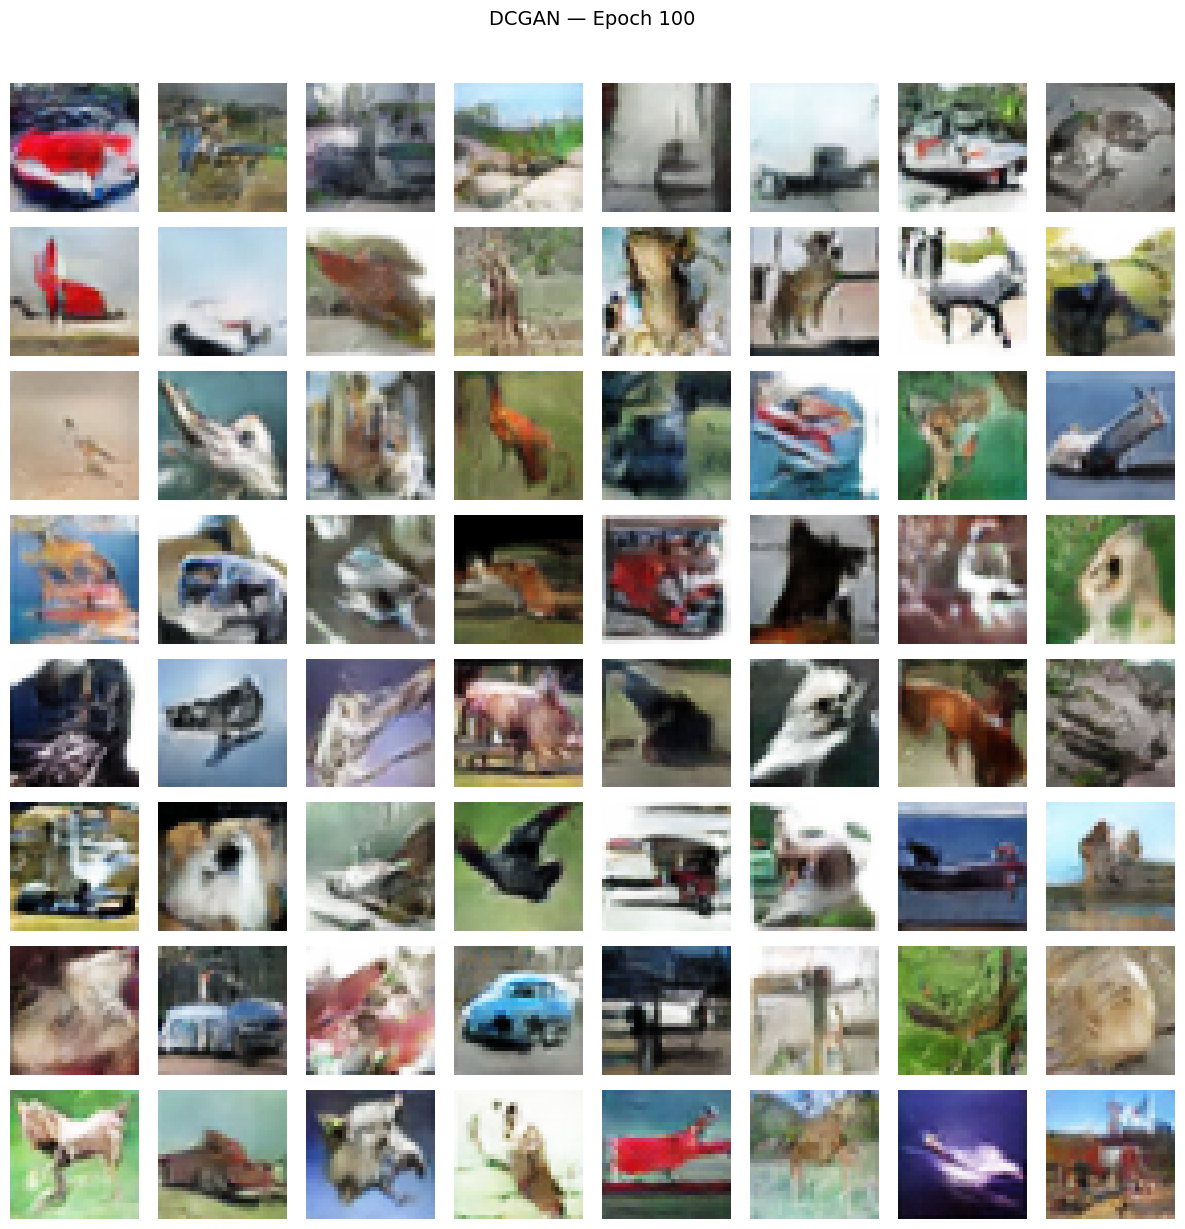

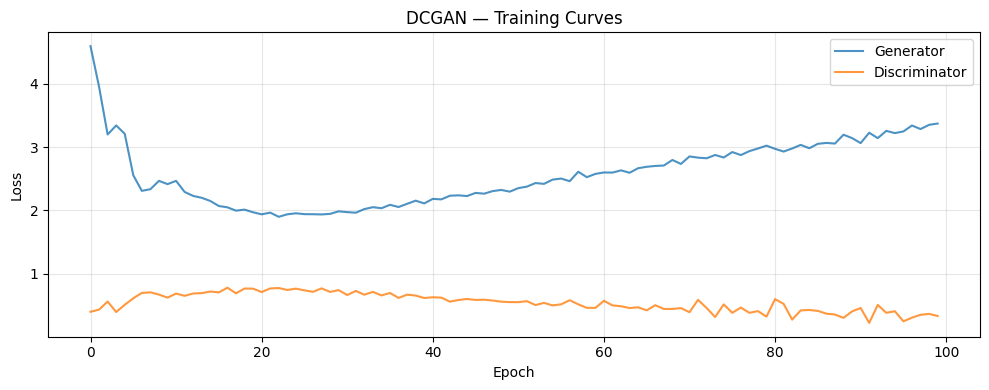


Final — G: 3.3714, D: 0.3299


In [2]:
# Step 2: DCGAN (Deep Convolutional GAN)

"""
Same architecture as PyTorch DCGAN for direct comparison.
DCGAN paper guidelines applied to Keras:
- Generator: Conv2DTranspose for upsampling (4x4 → 32x32)
- Discriminator: strided Conv2D for downsampling (32x32 → 1)
- BatchNormalization in both (except D input layer and G output layer)
- ReLU in G, LeakyReLU(0.2) in D
- Weight init: Normal(0, 0.02)

TF-specific: Dense+Reshape replaces ConvTranspose2d(z,256,4,1,0) since
Keras Sequential doesn't support 4D input. tf.GradientTape for manual
G/D update alternation — model.fit() can't do adversarial training.
"""

import matplotlib.pyplot as plt

print("=" * 60)
print("[2/6] DCGAN — CONVOLUTIONAL ARCHITECTURE")
print("=" * 60)

# Weight Initialization (DCGAN paper)
def init_weights(model):
    """Apply DCGAN weight init: Conv/Dense kernels ~ N(0, 0.02), BN gamma ~ N(1, 0.02)."""
    for layer in model.layers:
        if isinstance(layer, (keras.layers.Conv2D, keras.layers.Conv2DTranspose,
                              keras.layers.Dense)):
            if hasattr(layer, 'kernel') and layer.kernel is not None:
                layer.kernel.assign(tf.random.normal(layer.kernel.shape, 0.0, 0.02))
        elif isinstance(layer, keras.layers.BatchNormalization):
            if layer.gamma is not None:
                layer.gamma.assign(tf.random.normal(layer.gamma.shape, 1.0, 0.02))
            if layer.beta is not None:
                layer.beta.assign(tf.zeros(layer.beta.shape))


# Architectures

def build_dc_generator(latent_dim=LATENT_DIM):
    """
    DCGAN Generator: z(100) -> Dense -> Reshape(4,4,256) -> (32,32,3).
    4x4 -> 8x8 -> 16x16 -> 32x32 via transposed convolutions.
    """
    return keras.Sequential([
        # z(100) -> (4, 4, 256) — Dense+Reshape replaces PT's ConvT(z,256,4,1,0)
        keras.layers.Dense(256 * 4 * 4, use_bias=False, input_shape=(latent_dim,)),
        keras.layers.Reshape((4, 4, 256)),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        # (4, 4, 256) -> (8, 8, 128)
        keras.layers.Conv2DTranspose(128, 4, strides=2, padding='same', use_bias=False),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        # (8, 8, 128) -> (16, 16, 64)
        keras.layers.Conv2DTranspose(64, 4, strides=2, padding='same', use_bias=False),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        # (16, 16, 64) -> (32, 32, 3)
        keras.layers.Conv2DTranspose(IMAGE_CHANNELS, 4, strides=2, padding='same',
                                      use_bias=False, activation='tanh'),
    ])

def build_dc_discriminator():
    """
    DCGAN Discriminator: (32,32,3) -> scalar via strided convolutions.
    32x32 -> 16x16 -> 8x8 -> 4x4 -> 1
    """
    return keras.Sequential([
        # (32, 32, 3) -> (16, 16, 64) — no BN on first layer
        keras.layers.Conv2D(64, 4, strides=2, padding='same', input_shape=(32, 32, 3)),
        keras.layers.LeakyReLU(0.2),
        # (16, 16, 64) -> (8, 8, 128)
        keras.layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),
        # (8, 8, 128) -> (4, 4, 256)
        keras.layers.Conv2D(256, 4, strides=2, padding='same', use_bias=False),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),
        # (4, 4, 256) -> 1 (flatten + dense — raw logit, sigmoid in loss)
        keras.layers.Flatten(),
        keras.layers.Dense(1),
    ])

# Build & Init
G_dc = build_dc_generator()
D_dc = build_dc_discriminator()

# Trigger weight creation with dummy forward pass
_ = G_dc(tf.random.normal([1, LATENT_DIM]))
_ = D_dc(tf.random.normal([1, 32, 32, 3]))

init_weights(G_dc)
init_weights(D_dc)

opt_G = keras.optimizers.Adam(learning_rate=LR, beta_1=BETAS[0], beta_2=BETAS[1])
opt_D = keras.optimizers.Adam(learning_rate=LR, beta_1=BETAS[0], beta_2=BETAS[1])
bce = keras.losses.BinaryCrossentropy(from_logits=True)

g_params = G_dc.count_params()
d_params = D_dc.count_params()
print(f"Generator params:     {g_params:,}")
print(f"Discriminator params: {d_params:,}")
print(f"Total params:         {g_params + d_params:,}")


# Training
DCGAN_EPOCHS = 100

def train_step_dcgan(real_images):
    """Single training step: update D then G."""
    batch_size = tf.shape(real_images)[0]

    # Train Discriminator
    noise = tf.random.normal([batch_size, LATENT_DIM])
    with tf.GradientTape() as d_tape:
        fake_images = G_dc(noise, training=True)
        real_output = D_dc(real_images, training=True)
        fake_output = D_dc(fake_images, training=True)
        real_loss = bce(tf.ones_like(real_output), real_output)
        fake_loss = bce(tf.zeros_like(fake_output), fake_output)
        d_loss = real_loss + fake_loss

    d_grads = d_tape.gradient(d_loss, D_dc.trainable_variables)
    opt_D.apply_gradients(zip(d_grads, D_dc.trainable_variables))

    # Train Generator
    noise = tf.random.normal([batch_size, LATENT_DIM])
    with tf.GradientTape() as g_tape:
        fake_images = G_dc(noise, training=True)
        fake_output = D_dc(fake_images, training=True)
        g_loss = bce(tf.ones_like(fake_output), fake_output)

    g_grads = g_tape.gradient(g_loss, G_dc.trainable_variables)
    opt_G.apply_gradients(zip(g_grads, G_dc.trainable_variables))

    return g_loss, d_loss

print(f"\nTraining for {DCGAN_EPOCHS} epochs...")

g_losses_dc = []
d_losses_dc = []
start_time = time.time()

for epoch in range(DCGAN_EPOCHS):
    g_loss_epoch = 0.0
    d_loss_epoch = 0.0
    n_batches = 0

    for real_batch in train_dataset:
        g_loss, d_loss = train_step_dcgan(real_batch)
        g_loss_epoch += g_loss.numpy()
        d_loss_epoch += d_loss.numpy()
        n_batches += 1

    g_losses_dc.append(g_loss_epoch / n_batches)
    d_losses_dc.append(d_loss_epoch / n_batches)

    if (epoch + 1) % 20 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"  Epoch [{epoch+1:>3}/{DCGAN_EPOCHS}] | "
              f"D loss: {d_losses_dc[-1]:.4f} | "
              f"G loss: {g_losses_dc[-1]:.4f} | "
              f"{elapsed:.1f}s")

dcgan_time = time.time() - start_time
print(f"\nDCGAN training complete: {dcgan_time:.1f}s ({dcgan_time/60:.1f} min)")

# Generate & Display
dcgan_samples = G_dc(fixed_noise, training=False).numpy()

plot_generated_grid(dcgan_samples, nrow=8,
                    title='DCGAN — Epoch 100',
                    save_path=f'{RESULTS_DIR}/dcgan_samples.png')

# Training curves
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(g_losses_dc, label='Generator', alpha=0.8)
ax.plot(d_losses_dc, label='Discriminator', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('DCGAN — Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/dcgan_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal — G: {g_losses_dc[-1]:.4f}, D: {d_losses_dc[-1]:.4f}")

[3/6] EVALUATION — VISUAL COMPARISON


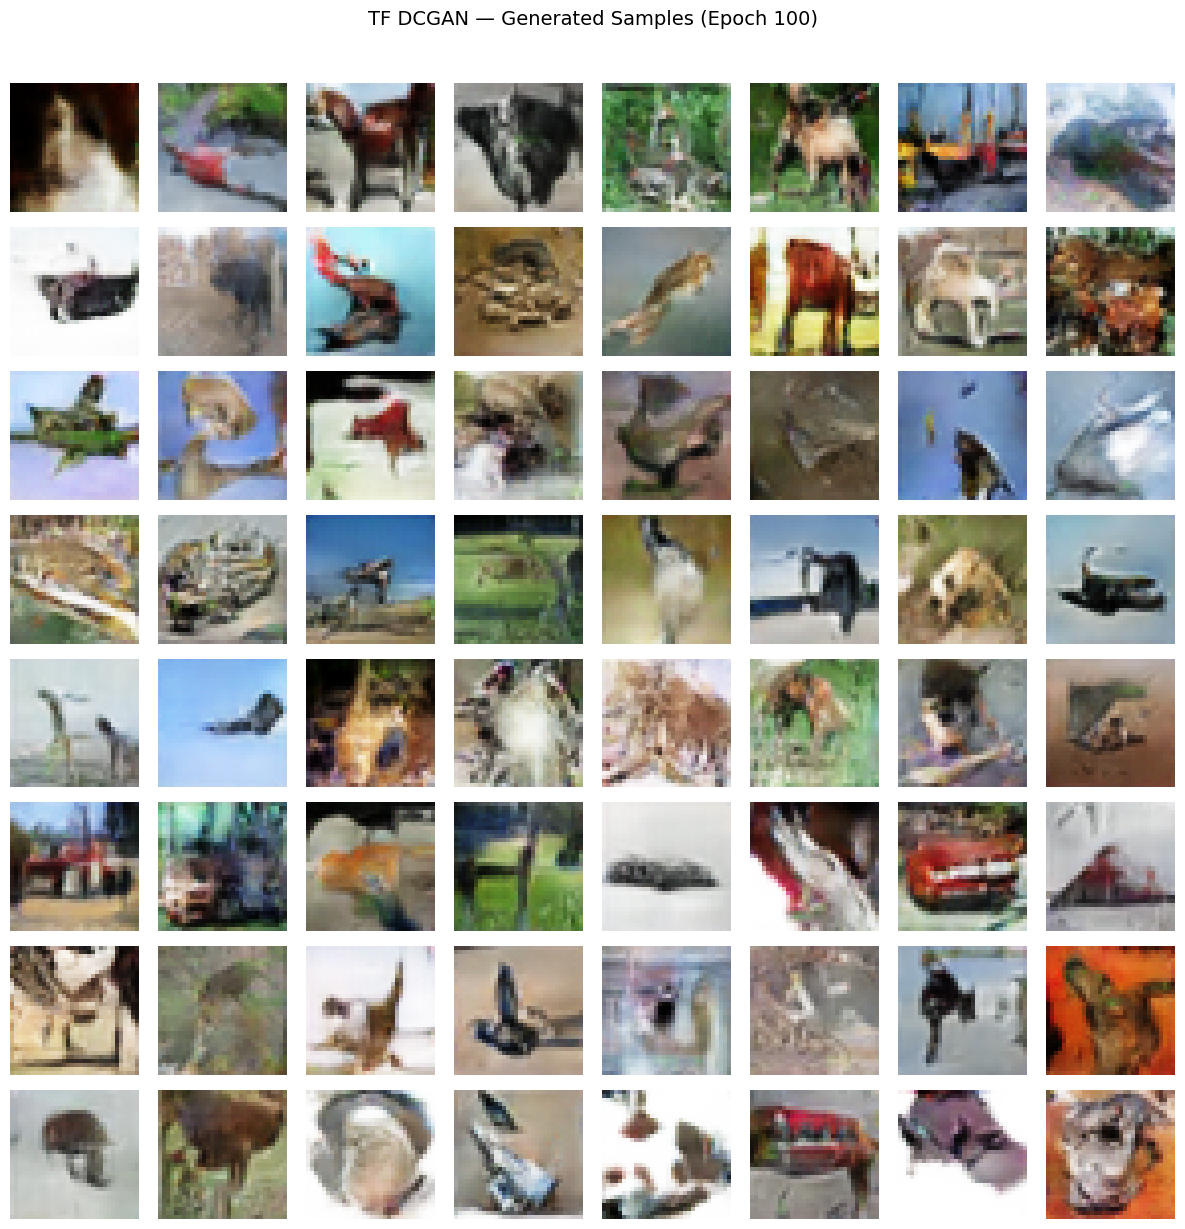


Training Dynamics:
  Final G loss: 3.3714
  Final D loss: 0.3299
  G/D loss ratio: 10.22
  D winning: Yes (D < 0.5)

  Epoch 1:   G=4.5944  D=0.3963
  Epoch 50:  G=2.2951  D=0.5491
  Epoch 100: G=3.3714  D=0.3299


In [4]:
# Step 3: Evaluation (Visual Comparison)

"""
FID computation skipped — compute_fid uses PyTorch InceptionV3, which
runs on CPU in the WSL2 TF environment (no dual-framework GPU sharing).
Visual evaluation + training curve analysis instead.
PT FID reference: DCGAN = 30.57.
"""

import matplotlib.pyplot as plt

print("=" * 60)
print("[3/6] EVALUATION — VISUAL COMPARISON")
print("=" * 60)

# Generate fresh samples
eval_noise = tf.random.normal([64, LATENT_DIM], seed=42)
eval_samples = G_dc(eval_noise, training=False).numpy()

plot_generated_grid(eval_samples, nrow=8,
                    title='TF DCGAN — Generated Samples (Epoch 100)',
                    save_path=f'{RESULTS_DIR}/dcgan_eval_grid.png')

# Training dynamics analysis
print(f"\nTraining Dynamics:")
print(f"  Final G loss: {g_losses_dc[-1]:.4f}")
print(f"  Final D loss: {d_losses_dc[-1]:.4f}")
print(f"  G/D loss ratio: {g_losses_dc[-1] / d_losses_dc[-1]:.2f}")
print(f"  D winning: {'Yes' if d_losses_dc[-1] < 0.5 else 'No'} (D < 0.5)")

# Loss trajectory
print(f"\n  Epoch 1:   G={g_losses_dc[0]:.4f}  D={d_losses_dc[0]:.4f}")
print(f"  Epoch 50:  G={g_losses_dc[49]:.4f}  D={d_losses_dc[49]:.4f}")
print(f"  Epoch 100: G={g_losses_dc[-1]:.4f}  D={d_losses_dc[-1]:.4f}")

In [6]:
# Step 4: Performance Benchmarks

"""
Training time, inference speed, model size, GPU memory.
Cross-framework comparison against PyTorch.
"""

print("=" * 60)
print("[4/6] PERFORMANCE BENCHMARKS")
print("=" * 60)

# Training time (already measured)
print(f"\nTraining:")
print(f"  DCGAN: {dcgan_time:.1f}s ({dcgan_time/60:.1f} min) — 100 epochs")
print(f"  Per epoch: {dcgan_time/DCGAN_EPOCHS:.2f}s")

# Inference speed — time generation of single batches
import time

# Warm up
_ = G_dc(tf.random.normal([1, LATENT_DIM]), training=False)

n_runs = 100
start = time.time()
for _ in range(n_runs):
    _ = G_dc(tf.random.normal([BATCH_SIZE, LATENT_DIM]), training=False)
inference_time = time.time() - start
per_sample = (inference_time / (n_runs * BATCH_SIZE)) * 1e6  # microseconds

print(f"\nInference:")
print(f"  {n_runs} batches of {BATCH_SIZE}: {inference_time:.2f}s")
print(f"  Per sample: {per_sample:.2f} µs")

# Model size (generator only — that's what gets deployed)
g_size = get_model_size(G_dc, framework='tensorflow')
print(f"\nGenerator size: {g_size}")

# GPU memory
if gpus:
    mem_info = tf.config.experimental.get_memory_info('GPU:0')
    peak_mb = mem_info['peak'] / (1024 ** 2)
    print(f"GPU peak memory: {peak_mb:.0f} MB")

# Cross-framework comparison
print(f"\n{'=' * 60}")
print(f"Cross-Framework Comparison:")
print(f"{'=' * 60}")
print(f"  {'Metric':<25} {'PyTorch':>12} {'TensorFlow':>12}")
print(f"  {'-' * 49}")
print(f"  {'Training time':<25} {'319s (5.3m)':>12} {f'{dcgan_time:.0f}s ({dcgan_time/60:.1f}m)':>12}")
print(f"  {'Per sample inference':<25} {'6.01 µs':>12} {f'{per_sample:.2f} µs':>12}")
print(f"  {'GPU memory':<25} {'345 MB':>12} {f'{peak_mb:.0f} MB' if gpus else 'N/A':>12}")
print(f"  {'FID (DCGAN)':<25} {'30.57':>12} {'N/A':>12}")

[4/6] PERFORMANCE BENCHMARKS

Training:
  DCGAN: 4737.9s (79.0 min) — 100 epochs
  Per epoch: 47.38s

Inference:
  100 batches of 128: 0.56s
  Per sample: 43.39 µs

Generator size: 4275712
GPU peak memory: 1078 MB

Cross-Framework Comparison:
  Metric                         PyTorch   TensorFlow
  -------------------------------------------------
  Training time              319s (5.3m) 4738s (79.0m)
  Per sample inference           6.01 µs     43.39 µs
  GPU memory                      345 MB      1078 MB
  FID (DCGAN)                      30.57          N/A


In [7]:
# Step 5: Save Results

"""
Save DCGAN generator weights and results for cross-framework comparison.
Match PT save format — manual results dict (generative models have no evaluate_classifier).
"""

print("=" * 60)
print("[5/6] SAVE RESULTS")
print("=" * 60)

# Save model weights
G_dc.save_weights(f'{RESULTS_DIR}/dcgan_generator.weights.h5')
D_dc.save_weights(f'{RESULTS_DIR}/dcgan_discriminator.weights.h5')
print(f"Models saved: {RESULTS_DIR}/dcgan_generator.weights.h5, dcgan_discriminator.weights.h5")

# Save training history
np.savez(f'{RESULTS_DIR}/dcgan_history.npz',
         g_losses=np.array(g_losses_dc),
         d_losses=np.array(d_losses_dc))
print(f"Training history saved: {RESULTS_DIR}/dcgan_history.npz")

# Build results dict (manual — generative models have no evaluate_classifier output)
g_size = get_model_size(G_dc, framework='tensorflow')

results = {
    'framework': 'TensorFlow',
    'model': 'DCGAN',
    'fid_score': 'N/A (compute_fid uses PT InceptionV3 — CPU only in WSL2)',
    'training_time': float(dcgan_time),
    'per_epoch_time': float(dcgan_time / DCGAN_EPOCHS),
    'inference_time_per_sample_us': float((inference_time / (n_runs * BATCH_SIZE)) * 1e6),
    'model_size_bytes': int(g_size),
    'peak_memory_mb': float(mem_info['peak'] / (1024 ** 2)) if gpus else 'N/A',
    'n_params_generator': int(G_dc.count_params()),
    'n_params_discriminator': int(D_dc.count_params()),
    'epochs': DCGAN_EPOCHS,
    'latent_dim': LATENT_DIM,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'variants_trained': ['DCGAN'],
    'variants_skipped': ['WGAN-GP (PT showed worse FID, 6h+ estimated on TF WSL2)'],
    'notes': 'WSL2 GPU — 15x slower than PT due to /mnt/c/ filesystem overhead'
}

# Save to local results/
save_results(results, save_dir='results')

# Save to shared cross-framework comparison
add_result('gans', results)

# Print cross-framework comparison table
print_comparison('gans')

[5/6] SAVE RESULTS
Models saved: results/dcgan_generator.weights.h5, dcgan_discriminator.weights.h5
Training history saved: results/dcgan_history.npz
    Results saved to: results/metrics.json
    Added 'TensorFlow' to /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/results/gans.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON: GANS
Metric                                                                                                                                                       PyTorch                                                                                                                            TensorFlow
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
model                      